# 7CS030 — Concept and Technology of AI
**Reproducible Figures & Tables Notebook**
**Student:** Augusta Ginikanwa (2428470)

> Ensure `houseprice_data.csv`, `country_data.csv`, and `nba_rookie_data.csv` are in the same folder as this notebook.


In [1]:

import os, math, warnings
warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (r2_score, mean_squared_error, silhouette_score, confusion_matrix,
                             accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc, roc_auc_score)
from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier

np.random.seed(42)

def save_show(fig, filename, dpi=300):
    fig.tight_layout(); fig.savefig(filename, dpi=dpi, bbox_inches="tight"); plt.show()


## Task 1 — Regression (houseprice_data.csv)

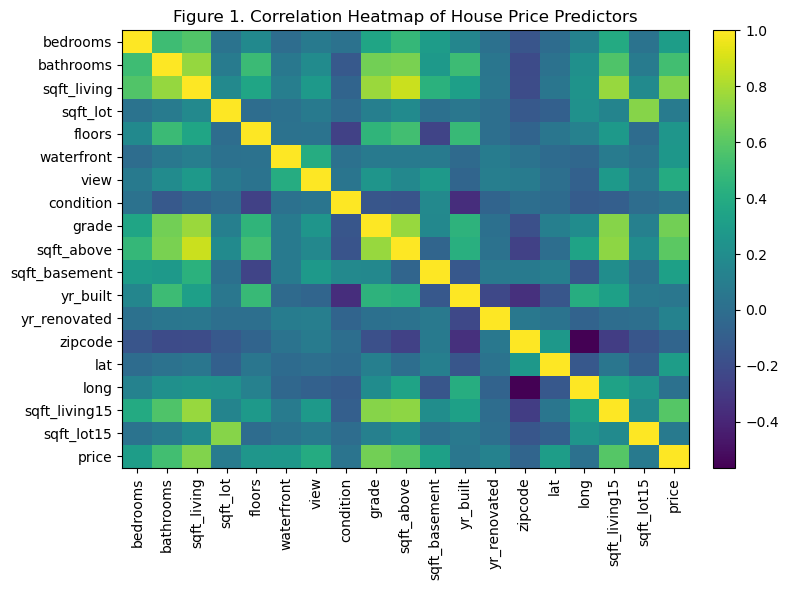

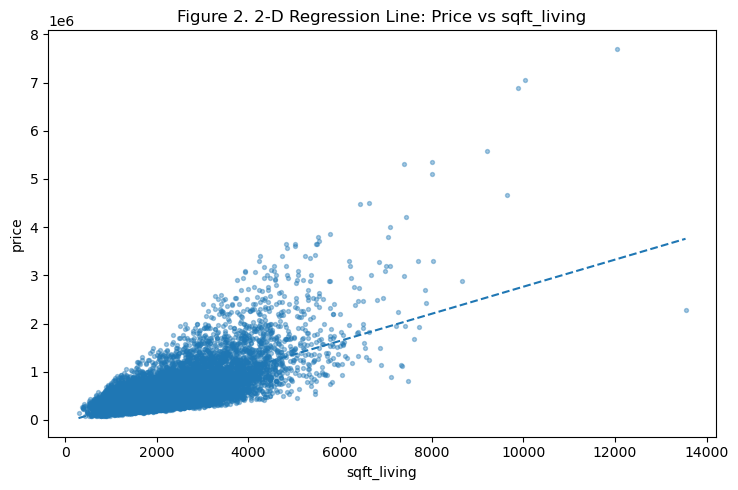

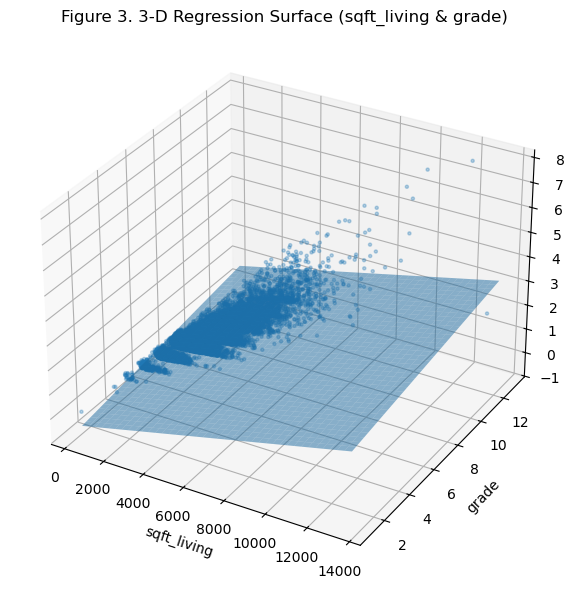

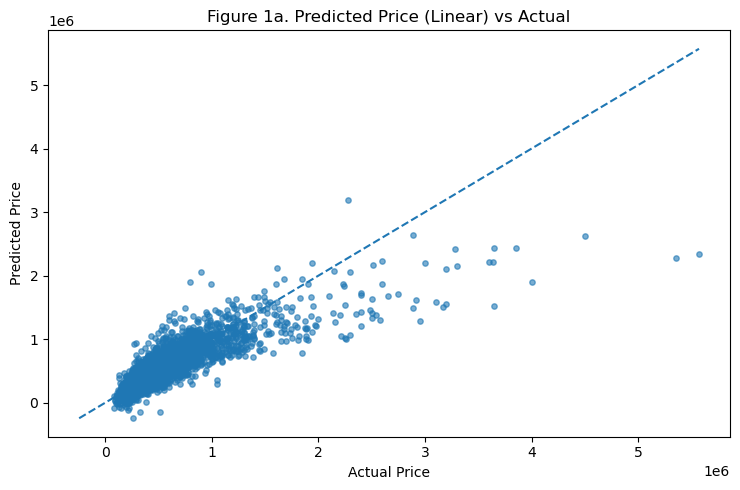

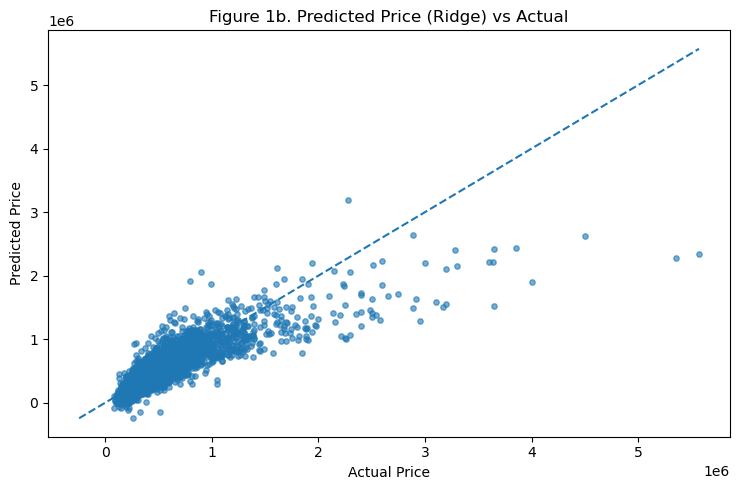

,Model,RMSE,R²
0,Linear Regression,212661.407511,0.701199
1,Ridge Regression,212689.567113,0.701120


,Feature,Abs_Coefficient
0,grade,112824.729907
1,lat,83527.765043
2,sqft_living,81864.175057
3,yr_built,77027.358863
4,sqft_above,76352.444772
5,waterfront,50439.825600
6,view,40563.373251
7,bedrooms,33293.383475
8,bathrooms,31704.389150
9,zipcode,31169.791266


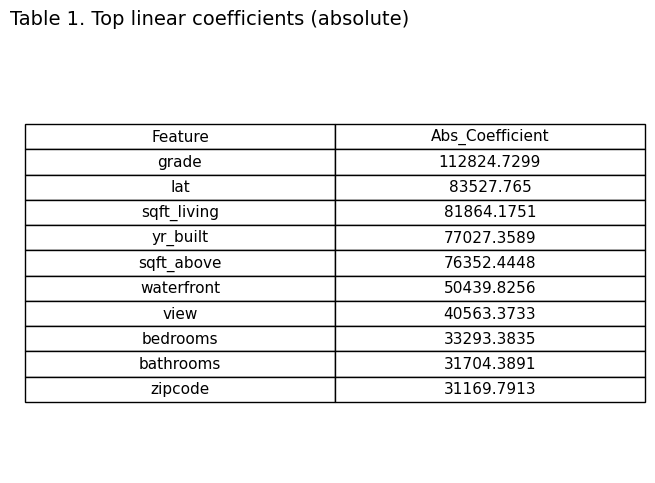

In [2]:

df_hp = pd.read_csv("houseprice_data.csv").dropna()
price_col = [c for c in df_hp.columns if c.lower() in ("price","saleprice")][0]
Xnum = df_hp.drop(columns=[price_col]).select_dtypes(include=np.number)
y = df_hp[price_col].values

# Heatmap
corr = Xnum.join(df_hp[price_col]).corr()
fig = plt.figure(figsize=(8,6)); ax = fig.add_subplot(111)
im = ax.imshow(corr.values, aspect='auto')
ax.set_xticks(range(len(corr.columns))); ax.set_yticks(range(len(corr.index)))
ax.set_xticklabels(corr.columns, rotation=90); ax.set_yticklabels(corr.index)
ax.set_title("Figure 1. Correlation Heatmap of House Price Predictors")
fig.colorbar(im, fraction=0.046, pad=0.04)
save_show(fig, "Figure1_Heatmap.png")

# 2-D regression
area_candidates = [c for c in Xnum.columns if 'sqft_living' in c.lower()]
area_col = area_candidates[0] if area_candidates else corr[price_col].drop(price_col).abs().sort_values(ascending=False).index[0]
lin2d = LinearRegression().fit(df_hp[[area_col]], df_hp[price_col])
x_line = np.linspace(df_hp[area_col].min(), df_hp[area_col].max(), 200).reshape(-1,1)
y_line = lin2d.predict(x_line)
fig = plt.figure(figsize=(7.5,5)); ax = fig.add_subplot(111)
ax.scatter(df_hp[area_col], df_hp[price_col], s=8, alpha=0.4)
ax.plot(x_line, y_line, linestyle='--')
ax.set_xlabel(area_col); ax.set_ylabel("price")
ax.set_title("Figure 2. 2-D Regression Line: Price vs " + area_col)
save_show(fig, "Figure2_2DRegression.png")

# 3-D regression surface with top2 predictors
corr_to_price = corr[price_col].drop(price_col).abs().sort_values(ascending=False)
top2 = corr_to_price.index[:2].tolist()
X2 = df_hp[top2].values; y2 = df_hp[price_col].values
lin3d = LinearRegression().fit(X2, y2)
xg = np.linspace(df_hp[top2[0]].min(), df_hp[top2[0]].max(), 40)
yg = np.linspace(df_hp[top2[1]].min(), df_hp[top2[1]].max(), 40)
Xg, Yg = np.meshgrid(xg, yg)
Zg = lin3d.predict(np.c_[Xg.ravel(), Yg.ravel()]).reshape(Xg.shape)
fig = plt.figure(figsize=(8,6)); ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(Xg, Yg, Zg, alpha=0.5)
ax.scatter(df_hp[top2[0]], df_hp[top2[1]], df_hp[price_col], s=5, alpha=0.3)
ax.set_xlabel(top2[0]); ax.set_ylabel(top2[1]); ax.set_zlabel("price")
ax.set_title(f"Figure 3. 3-D Regression Surface ({top2[0]} & {top2[1]})")
save_show(fig, "Figure3_3DRegression.png")

# Train/test and Pred vs Actual (Linear & Ridge)
X = Xnum.values
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42)
lin = LinearRegression().fit(Xtr, ytr)
ridge = Ridge(alpha=1.0, random_state=42).fit(Xtr, ytr)
yp_lin = lin.predict(Xte); yp_rdg = ridge.predict(Xte)

def pvaplot(y_true, y_hat, title, fname):
    fig = plt.figure(figsize=(7.5,5)); ax = fig.add_subplot(111)
    ax.scatter(y_true, y_hat, alpha=0.6, s=15)
    lo, hi = min(y_true.min(), y_hat.min()), max(y_true.max(), y_hat.max())
    ax.plot([lo,hi],[lo,hi],'--')
    ax.set_xlabel("Actual Price"); ax.set_ylabel("Predicted Price")
    ax.set_title(title); save_show(fig, fname)

pvaplot(yte, yp_lin, "Figure 1a. Predicted Price (Linear) vs Actual", "Figure1a_Pred_vs_Actual_Linear.png")
pvaplot(yte, yp_rdg, "Figure 1b. Predicted Price (Ridge) vs Actual", "Figure1b_Pred_vs_Actual_Ridge.png")

# Metrics & Top coefficients (absolute, z-scaled)
def rmse(a,b): 
    from sklearn.metrics import mean_squared_error
    import math
    return math.sqrt(mean_squared_error(a,b))

metrics = pd.DataFrame({
    "Model": ["Linear Regression", "Ridge Regression"],
    "RMSE":  [rmse(yte, yp_lin), rmse(yte, yp_rdg)],
    "R²":    [r2_score(yte, yp_lin), r2_score(yte, yp_rdg)]
})
display(metrics)

sc = StandardScaler().fit(Xnum.values)
Xz = sc.transform(Xnum.values)
lin_scaled = LinearRegression().fit(Xz, y)
abs_coef = np.abs(lin_scaled.coef_)
top_idx = np.argsort(abs_coef)[::-1][:10]
top_table = pd.DataFrame({"Feature": Xnum.columns[top_idx], "Abs_Coefficient": abs_coef[top_idx]})
display(top_table)

# Save the "table diagram" PNG
fig, ax = plt.subplots(figsize=(6.5, 4.5)); ax.axis("off")
fig.text(0.0, 1.03, "Table 1. Top linear coefficients (absolute)", fontsize=14, ha="left")
show_tbl = top_table.copy(); show_tbl["Abs_Coefficient"] = show_tbl["Abs_Coefficient"].round(4)
tbl = ax.table(cellText=show_tbl.values, colLabels=show_tbl.columns, loc="center", cellLoc="center", colLoc="center")
tbl.auto_set_font_size(False); tbl.set_fontsize(11); tbl.scale(1, 1.25)
save_show(fig, "Table1_TopLinearCoefficients.png")


## Task 2 — Clustering (country_data.csv)

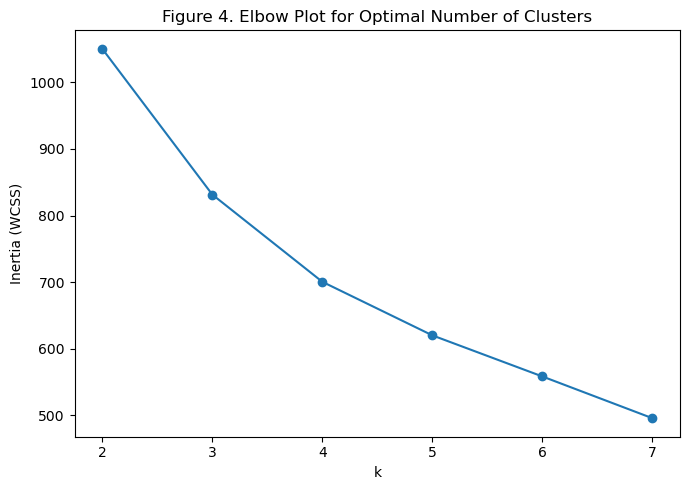

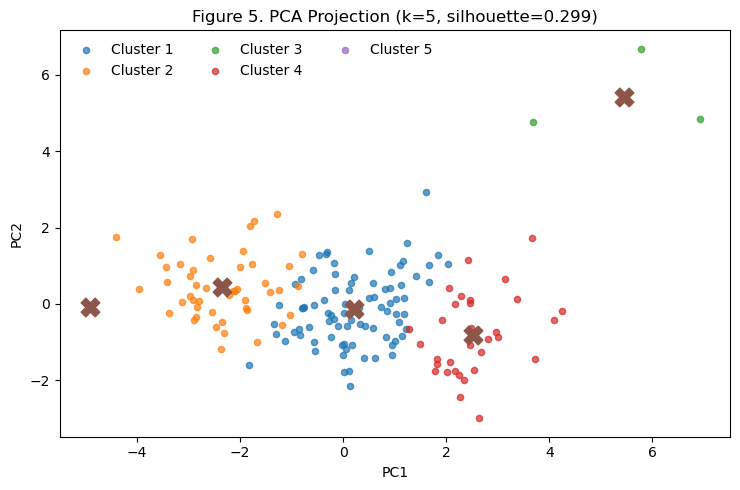

In [3]:

df_cty = pd.read_csv("country_data.csv").dropna()
Xc = df_cty.select_dtypes(include=np.number).values
sc_ct = StandardScaler(); Xc_s = sc_ct.fit_transform(Xc)

Ks = range(2, 8); inertia, sils = [], []
for k in Ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10).fit(Xc_s)
    inertia.append(km.inertia_)
    sils.append(silhouette_score(Xc_s, km.labels_))
best_k = Ks[int(np.argmax(sils))]

# Elbow (Figure 4)
fig = plt.figure(figsize=(7,5)); ax = fig.add_subplot(111)
ax.plot(list(Ks), inertia, marker='o')
ax.set_title("Figure 4. Elbow Plot for Optimal Number of Clusters")
ax.set_xlabel("k"); ax.set_ylabel("Inertia (WCSS)")
save_show(fig, "Figure4_ElbowPlot.png")

# PCA clusters with centroids (Figure 5)
km_best = KMeans(n_clusters=best_k, random_state=42, n_init=10).fit(Xc_s)
labels = km_best.labels_
pca = PCA(n_components=2, random_state=42).fit(Xc_s)
Xp = pca.transform(Xc_s); cent = pca.transform(km_best.cluster_centers_)

fig = plt.figure(figsize=(7.5,5)); ax = fig.add_subplot(111)
for i in range(best_k):
    ax.scatter(Xp[labels==i,0], Xp[labels==i,1], s=20, alpha=0.7, label=f"Cluster {i+1}")
ax.scatter(cent[:,0], cent[:,1], s=180, marker='X')
ax.set_title(f"Figure 5. PCA Projection (k={best_k}, silhouette={max(sils):.3f})")
ax.set_xlabel("PC1"); ax.set_ylabel("PC2"); ax.legend(frameon=False, ncol=min(3,best_k))
save_show(fig, "Figure5_PCAClusters.png")


## Task 3 — Classification (nba_rookie_data.csv)

,Model,Accuracy,Precision_1,Recall_1,F1_1,ROC_AUC
0,Logistic Regression,0.711779,0.747212,0.810484,0.777563,0.765114
2,Neural Network (MLP),0.619048,0.698347,0.681452,0.689796,0.676912
1,Gaussian Naïve Bayes,0.626566,0.823529,0.508065,0.628429,0.735380


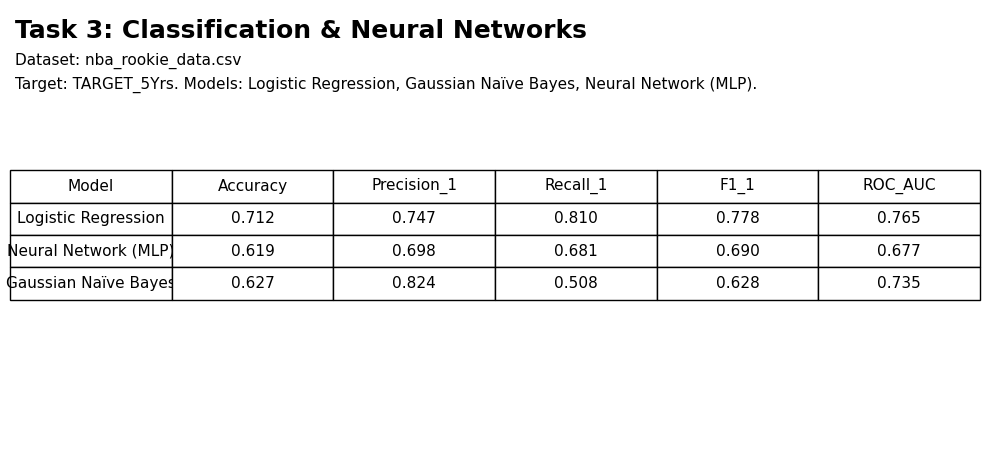

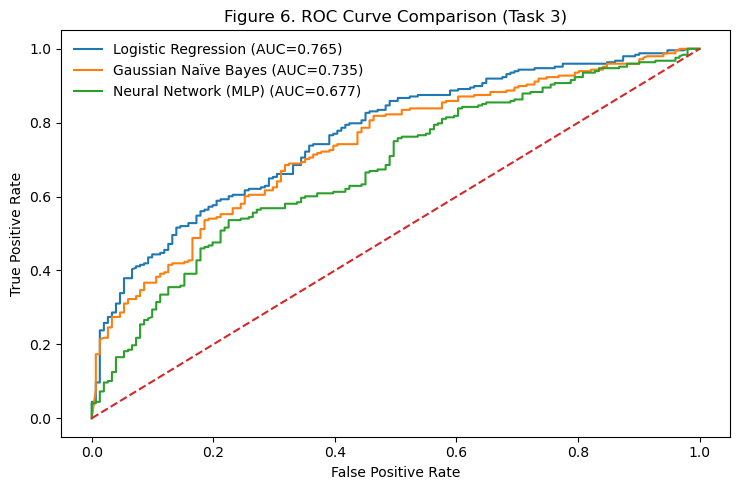

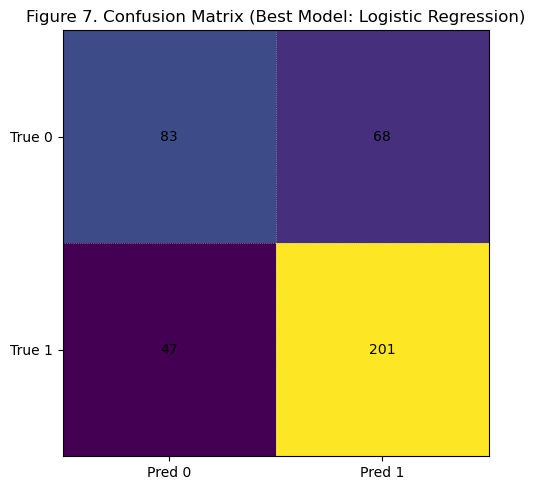

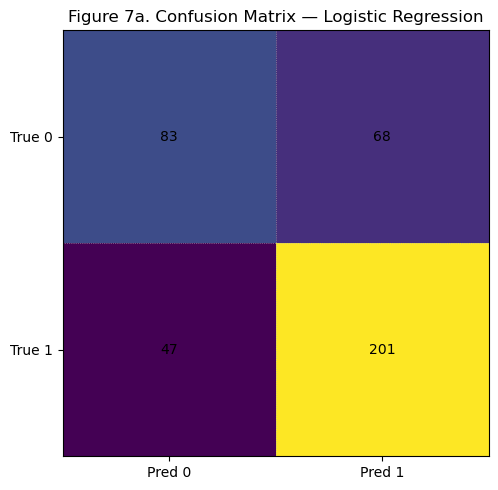

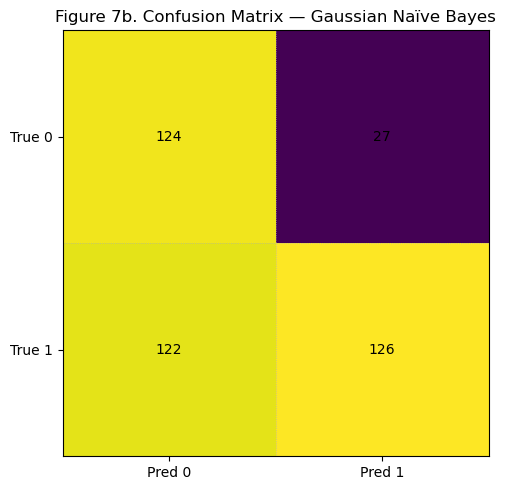

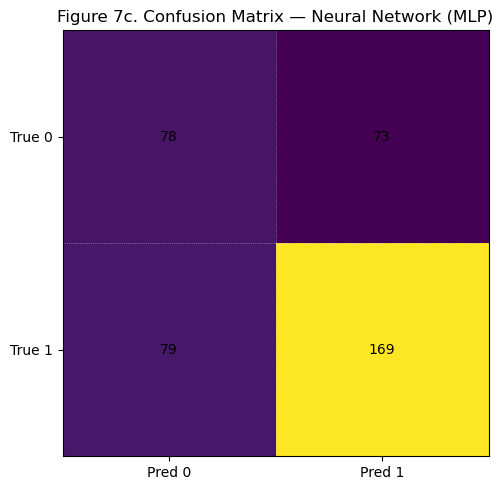

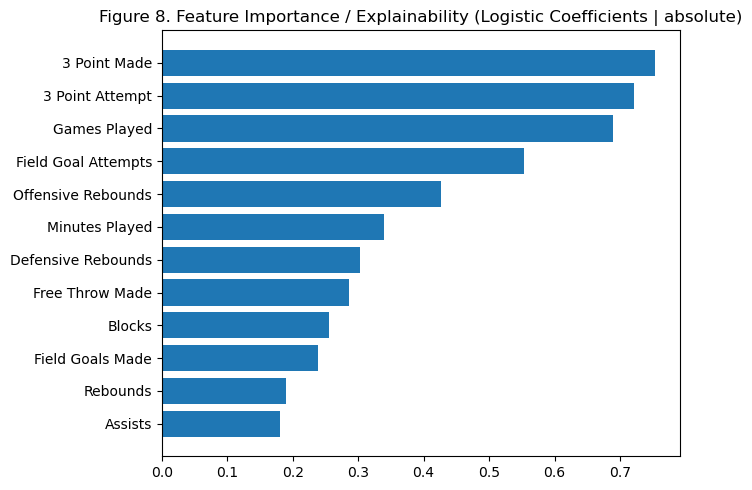

In [4]:

df_nba = pd.read_csv("nba_rookie_data.csv").dropna()
assert "TARGET_5Yrs" in df_nba.columns

Xn = df_nba.drop(columns=["TARGET_5Yrs"]).select_dtypes(include=np.number).values
yn = df_nba["TARGET_5Yrs"].values

Xtr, Xte, ytr, yte = train_test_split(Xn, yn, test_size=0.30, random_state=42, stratify=yn)
sc_nb = StandardScaler(); Xtr = sc_nb.fit_transform(Xtr); Xte = sc_nb.transform(Xte)

models = {
    "Logistic Regression": LogisticRegression(max_iter=600),
    "Gaussian Naïve Bayes": GaussianNB(),
    "Neural Network (MLP)": MLPClassifier(hidden_layer_sizes=(32,16,8), max_iter=800, random_state=42)
}

rows, probs, cms = [], {}, {}
for name, m in models.items():
    m.fit(Xtr, ytr)
    yp = m.predict(Xte)
    pr = m.predict_proba(Xte)[:,1]
    rows.append([name,
                 accuracy_score(yte, yp),
                 precision_score(yte, yp),
                 recall_score(yte, yp),
                 f1_score(yte, yp),
                 roc_auc_score(yte, pr)])
    probs[name] = pr
    cms[name] = confusion_matrix(yte, yp)

results = pd.DataFrame(rows, columns=["Model","Accuracy","Precision_1","Recall_1","F1_1","ROC_AUC"]).sort_values("F1_1", ascending=False)
display(results)

# Model comparison table PNG
tbl = results.copy()
for c in ["Accuracy","Precision_1","Recall_1","F1_1","ROC_AUC"]:
    tbl[c] = tbl[c].map(lambda v: f"{v:.3f}")
fig = plt.figure(figsize=(10,4.8)); ax = fig.add_subplot(111); ax.axis("off")
fig.text(0.02, 0.95, "Task 3: Classification & Neural Networks", fontsize=18, fontweight='bold', va='top', ha='left')
fig.text(0.02, 0.88, "Dataset: nba_rookie_data.csv", fontsize=11, va='top', ha='left')
fig.text(0.02, 0.83, "Target: TARGET_5Yrs. Models: Logistic Regression, Gaussian Naïve Bayes, Neural Network (MLP).", fontsize=11, va='top', ha='left')
t = ax.table(cellText=tbl.values, colLabels=tbl.columns, loc='center', cellLoc='center', colLoc='center')
t.auto_set_font_size(False); t.set_fontsize(11); t.scale(1,1.6)
save_show(fig, "Task3_Model_Comparison_Table.png")

# ROC (Figure 6)
fig = plt.figure(figsize=(7.5,5)); ax = fig.add_subplot(111)
for name, pr in probs.items():
    fpr, tpr, _ = roc_curve(yte, pr)
    ax.plot(fpr, tpr, label=f"{name} (AUC={auc(fpr,tpr):.3f})")
ax.plot([0,1],[0,1],'--')
ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
ax.set_title("Figure 6. ROC Curve Comparison (Task 3)")
ax.legend(frameon=False)
save_show(fig, "Figure6_ROC.png")

# Confusion matrices (Figure 7, 7a, 7b, 7c)
def cm_plot(cm, title, filename):
    fig = plt.figure(figsize=(6,5)); ax = fig.add_subplot(111)
    im = ax.imshow(cm, interpolation='nearest')
    ax.set_title(title)
    ax.set_xticks([0,1]); ax.set_xticklabels(["Pred 0","Pred 1"])
    ax.set_yticks([0,1]); ax.set_yticklabels(["True 0","True 1"])
    for (i,j), v in np.ndenumerate(cm):
        ax.text(j, i, int(v), ha="center", va="center")
    ax.set_xticks(np.arange(-.5, 2, 1), minor=True)
    ax.set_yticks(np.arange(-.5, 2, 1), minor=True)
    ax.grid(which="minor", linestyle=":", linewidth=0.5)
    ax.tick_params(which="minor", bottom=False, left=False)
    save_show(fig, filename)

best_name = results.iloc[0]["Model"]
cm_plot(cms[best_name], "Figure 7. Confusion Matrix (Best Model: " + best_name + ")", "Figure7_ConfusionMatrix.png")
cm_plot(cms["Logistic Regression"], "Figure 7a. Confusion Matrix — Logistic Regression", "Figure7a_CM_Logistic.png")
cm_plot(cms["Gaussian Naïve Bayes"], "Figure 7b. Confusion Matrix — Gaussian Naïve Bayes", "Figure7b_CM_GNB.png")
cm_plot(cms["Neural Network (MLP)"], "Figure 7c. Confusion Matrix — Neural Network (MLP)", "Figure7c_CM_MLP.png")

# Logistic coefficients (Figure 8)
logit = LogisticRegression(max_iter=600).fit(Xtr, ytr)
colnames = df_nba.drop(columns=["TARGET_5Yrs"]).select_dtypes(include=np.number).columns
coefs = pd.Series(logit.coef_[0], index=colnames)
top_imp = coefs.abs().nlargest(12).sort_values()

fig = plt.figure(figsize=(7,5)); ax = fig.add_subplot(111)
ax.barh(top_imp.index, top_imp.values)
ax.set_title("Figure 8. Feature Importance / Explainability (Logistic Coefficients | absolute)")
save_show(fig, "Figure8_FeatureImportance.png")


## Task 4 — Ethical Framework (Figure 9)

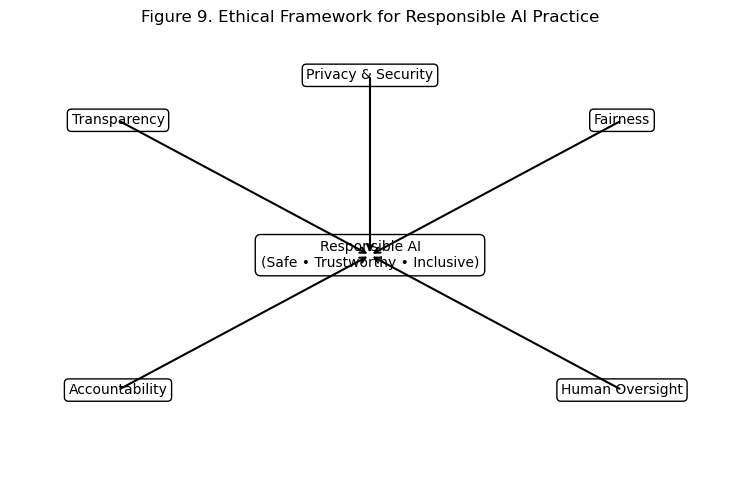

All figures and tables saved successfully.


In [5]:

fig = plt.figure(figsize=(7.5,5)); ax = fig.add_subplot(111)
ax.axis('off')
ax.text(0.5, 0.5, "Responsible AI\n(Safe • Trustworthy • Inclusive)", ha='center', va='center',
        bbox=dict(boxstyle="round,pad=0.4", ec="black", fc="white"))
items = [(0.15, 0.8, "Transparency"), (0.85, 0.8, "Fairness"),
         (0.15, 0.2, "Accountability"), (0.85, 0.2, "Human Oversight"),
         (0.5, 0.9, "Privacy & Security")]
for x,y,label in items:
    ax.text(x, y, label, ha='center', va='center',
            bbox=dict(boxstyle="round,pad=0.3", ec="black", fc="white"))
    ax.annotate("", xy=(0.5,0.5), xytext=(x,y), arrowprops=dict(arrowstyle="->", lw=1.5))
ax.set_title("Figure 9. Ethical Framework for Responsible AI Practice")
save_show(fig, "Figure9_EthicalFramework.png")
print("All figures and tables saved successfully.")


In [6]:
# Convert within Jupyter notebook itself
!jupyter nbconvert --to python 7CS030_Augusta_Ginikanwa_FINAL_Repro_Notebook.ipynb

[NbConvertApp] Converting notebook 7CS030_Augusta_Ginikanwa_FINAL_Repro_Notebook.ipynb to python
[NbConvertApp] Writing 12215 bytes to 7CS030_Augusta_Ginikanwa_FINAL_Repro_Notebook.py
